In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

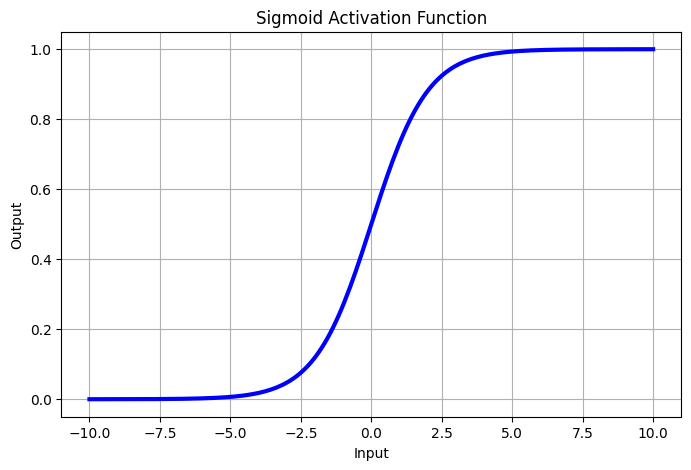

In [2]:
# Generate values

x = np.linspace(-10,10,200)

# Sigmoid Function

y = 1/(1+np.exp(-x))

# Plot

plt.figure(figsize=(8,5))

plt.plot(x,y,color="blue",linewidth=3)

plt.title("Sigmoid Activation Function")

plt.xlabel("Input")

plt.ylabel("Output")

plt.grid(True)

plt.show()

In [3]:
df = pd.read_csv("Titanic-Dataset.csv")

In [4]:
print("First Five Records")

print(df.head())

print("\nDataset Information")

print(df.info())

print("\nStatistical Summary")

print(df.describe())

First Five Records
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500 

In [5]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
# Handle Missing Values

df["Age"].fillna(df["Age"].median(), inplace=True)

df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Drop Cabin column because it contains many missing values

df.drop("Cabin", axis=1, inplace=True)

print("Missing Values After Preprocessing")

print(df.isnull().sum())

Missing Values After Preprocessing
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


C:\Users\shrad\AppData\Local\Temp\ipykernel_14468\1037778896.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
C:\Users\shrad\AppData\Local\Temp\ipykernel_14468\1037778896.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [7]:
# Remove Unnecessary Columns

df = df.drop(["Name", "Ticket"], axis=1)

print(df.head())

   PassengerId  Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0            1         0       3    male  22.0      1      0   7.2500        S
1            2         1       1  female  38.0      1      0  71.2833        C
2            3         1       3  female  26.0      0      0   7.9250        S
3            4         1       1  female  35.0      1      0  53.1000        S
4            5         0       3    male  35.0      0      0   8.0500        S


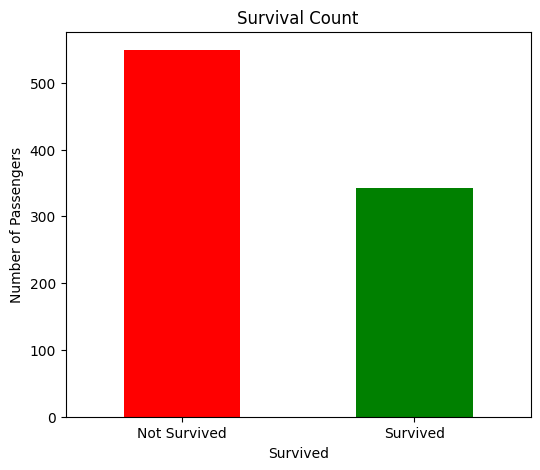

In [8]:
plt.figure(figsize=(6,5))

df["Survived"].value_counts().plot(
    kind="bar",
    color=["red","green"]
)

plt.title("Survival Count")

plt.xlabel("Survived")

plt.ylabel("Number of Passengers")

plt.xticks([0,1],["Not Survived","Survived"],rotation=0)

plt.show()

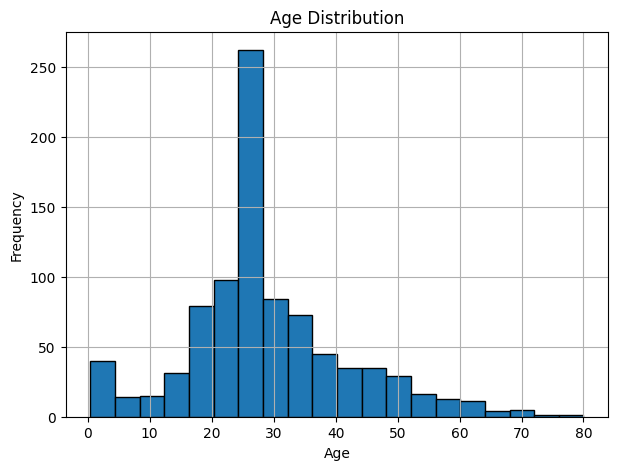

In [9]:
plt.figure(figsize=(7,5))

plt.hist(
    df["Age"],
    bins=20,
    edgecolor="black"
)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

In [10]:
label = LabelEncoder()

df["Sex"] = label.fit_transform(df["Sex"])

df["Embarked"] = label.fit_transform(df["Embarked"])

print(df.head())

   PassengerId  Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0            1         0       3    1  22.0      1      0   7.2500         2
1            2         1       1    0  38.0      1      0  71.2833         0
2            3         1       3    0  26.0      0      0   7.9250         2
3            4         1       1    0  35.0      1      0  53.1000         2
4            5         0       3    1  35.0      0      0   8.0500         2


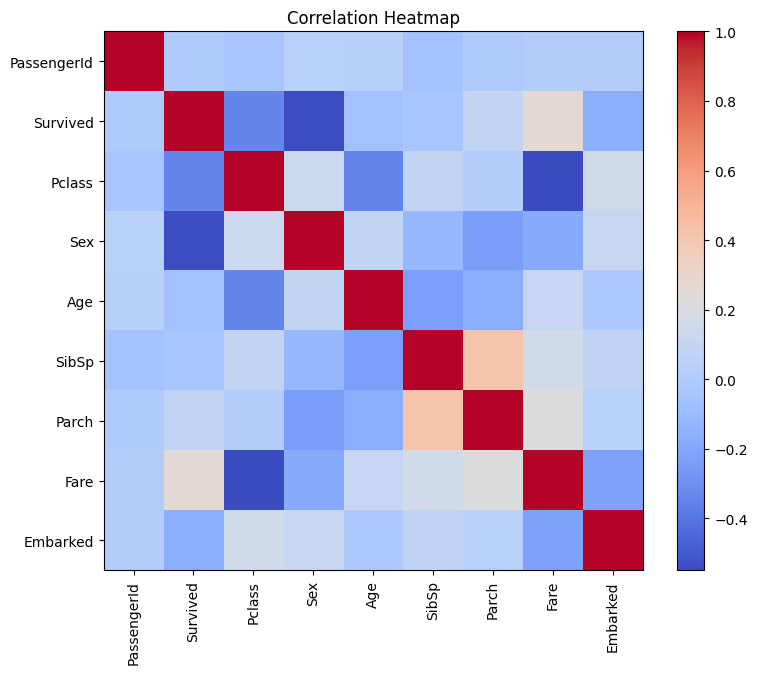

In [11]:
correlation = df.corr()

plt.figure(figsize=(9,7))

plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

plt.show()

In [12]:
# Feature and Target Split

X = df.drop("Survived", axis=1)

y = df["Survived"]

print("Feature Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Shape : (891, 8)
Target Shape : (891,)


In [13]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training Samples :", X_train.shape[0])

print("Testing Samples :", X_test.shape[0])

Training Samples : 712
Testing Samples : 179


In [14]:
# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


In [15]:
# Build ANN Model

model = Sequential([

    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),

    BatchNormalization(),

    Dropout(0.30),

    Dense(32, activation='relu'),

    BatchNormalization(),

    Dropout(0.30),

    Dense(1, activation='sigmoid')

])

model.summary()

C:\Users\shrad\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 192 (768.00 B)

In [16]:
# Compile Model

model.compile(

    optimizer=Adam(learning_rate=0.001),

    loss='binary_crossentropy',

    metrics=['accuracy']

)

In [17]:
# Early Stopping

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True

)

In [18]:
# Train the Model

history = model.fit(

    X_train,

    y_train,

    epochs=100,

    batch_size=32,

    validation_split=0.20,

    callbacks=[early_stop]

)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5975 - loss: 0.7822 - val_accuracy: 0.7273 - val_loss: 0.6246
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7504 - loss: 0.5855 - val_accuracy: 0.7972 - val_loss: 0.5757
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7469 - loss: 0.5456 - val_accuracy: 0.7832 - val_loss: 0.5445
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7487 - loss: 0.5561 - val_accuracy: 0.7902 - val_loss: 0.5213
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7750 - loss: 0.5021 - val_accuracy: 0.7832 - val_loss: 0.5075
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7663 - loss: 0.5024 - val_accuracy: 0.7832 - val_loss: 0.4978
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8190 - loss: 0.4647 - val_accuracy: 0.7832 - val_loss: 0.4892
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7926 - loss: 0.4844 - val_accuracy: 0.7832 - 

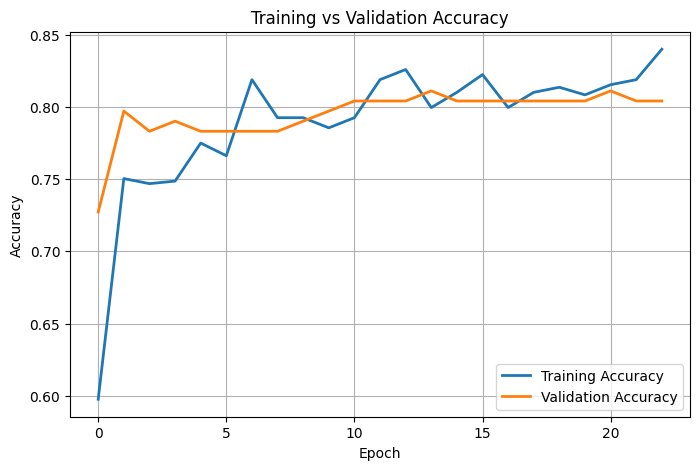

In [19]:
# Training vs Validation Accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)

plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

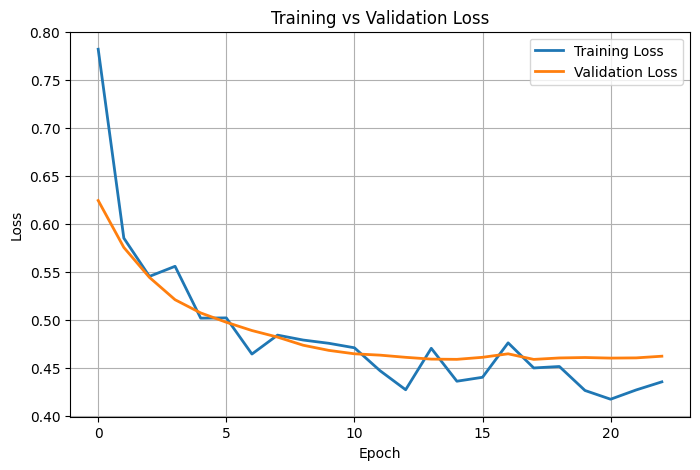

In [20]:
# Training vs Validation Loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss', linewidth=2)

plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [21]:
# Evaluate Model

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", loss)

print("Test Accuracy :", accuracy)

print(f"\nModel Accuracy : {accuracy*100:.2f}%")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8101 - loss: 0.4464 
Test Loss : 0.4464402496814728
Test Accuracy : 0.8100558519363403

Model Accuracy : 81.01%


In [22]:
# Predict Test Data

y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

print("First 10 Predictions")

print(y_pred[:10])

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
First 10 Predictions
[[0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]]


In [23]:
# Accuracy Score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score :", accuracy)

print(f"Accuracy Percentage : {accuracy*100:.2f}%")

Accuracy Score : 0.8100558659217877
Accuracy Percentage : 81.01%


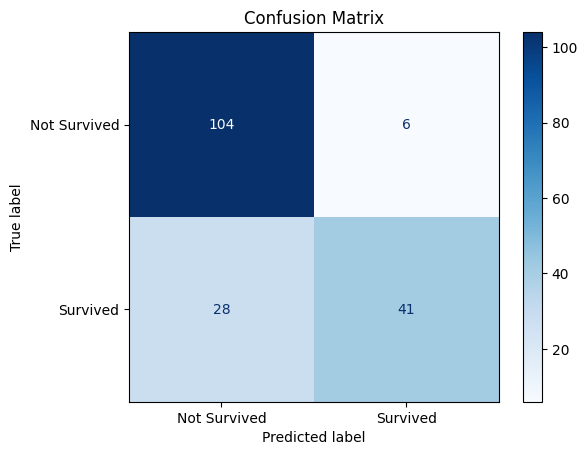

In [24]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Survived","Survived"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [25]:
# Classification Report

print("Classification Report\n")

print(classification_report(y_test, y_pred))

Classification Report

              precision    recall  f1-score   support

           0       0.79      0.95      0.86       110
           1       0.87      0.59      0.71        69

    accuracy                           0.81       179
   macro avg       0.83      0.77      0.78       179
weighted avg       0.82      0.81      0.80       179



In [26]:
comparison = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": y_pred.flatten()

})

print(comparison.head(15))

    Actual  Predicted
0        0          0
1        0          0
2        1          0
3        0          0
4        1          1
5        1          0
6        1          1
7        0          0
8        0          0
9        0          0
10       0          0
11       0          0
12       1          0
13       0          0
14       0          0


<Figure size 1000x500 with 0 Axes>

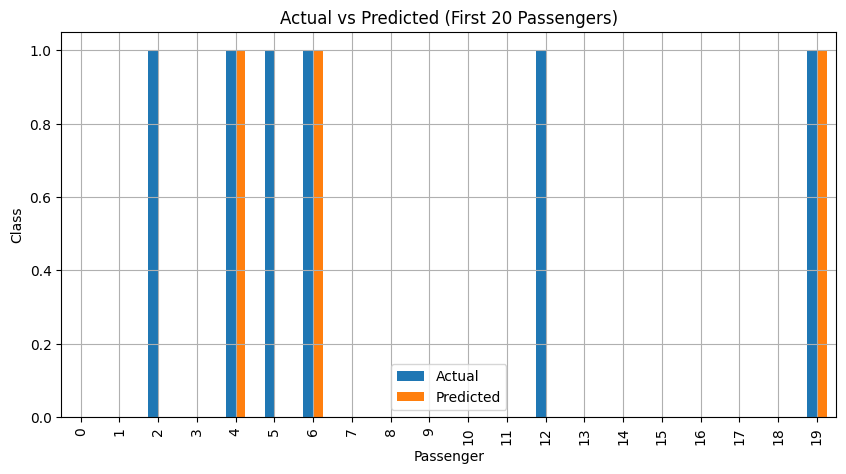

In [27]:
plt.figure(figsize=(10,5))

comparison.head(20).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Actual vs Predicted (First 20 Passengers)")

plt.xlabel("Passenger")

plt.ylabel("Class")

plt.grid(True)

plt.show()